<a href="https://colab.research.google.com/github/RyanPile/CSC215-Project/blob/main/CSC215_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geo-Aware Machine Learning for Hospitality Suitability: An Explainable Scoring Model (Case Study: Airbnb)
---
## Group Delta -  Bilal, Jeremy Auradou, Elliott, Ryan

Datasets: https://insideairbnb.com/get-the-data/


Datasets currently included:
*   Oakland, California, United States (25 September, 2025)
*   San Francisco, California, United States (01 September, 2025)
*   San Mateo County, California, United States (25 September, 2025)
*   Santa Clara County, California, United States (25 September, 2025)

# Library Imports and Display Options

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(f'Pandas Version: {pd.__version__}')
print(f'Numpy Version: {np.__version__}')

Pandas Version: 2.2.2
Numpy Version: 2.0.2


### Import Oakland Dataset

In [ ]:
oakland_dataset = pd.read_csv('https://raw.githubusercontent.com/JeremyAuradou/CSC215-FinalProject/refs/heads/main/listings_oakland.csv', header=0, index_col=False)

print('Oakland Dataset Shape:')
print(oakland_dataset.shape)
print('Oakland Dataset Head:')
display(oakland_dataset.head())
print('Oakland Dataset Tail:')
display(oakland_dataset.tail())

Oakland Dataset Shape:
(2250, 79)
Oakland Dataset Head:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3083,https://www.airbnb.com/rooms/3083,20250925032724,2025-09-25,city scrape,Room #2 - West Oakland,"4 blocks from West Oakland BART, 1 stop to San...",The neighborhood is in a historic district wit...,https://a0.muscache.com/pictures/hosting/Hosti...,3518,https://www.airbnb.com/users/show/3518,Traci,2008-10-08,"Oakland, CA","Hello! I am Traci, an Artist and activist who ...",within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/40746...,https://a0.muscache.com/im/pictures/user/40746...,Prescott,7.0,7.0,"['email', 'phone']",t,t,Neighborhood highlights,Prescott,NaN,37.810130,-122.292660,Private room in home,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Self check-in"", ""Coffee maker"", ""Private bac...",$125.00,1,365,1.0,1.0,365.0,1125.0,1.0,943.8,NaN,t,21,51,81,87,2025-09-25,78,12,1,87,7,72,9000.0,2014-08-02,2025-08-28,4.74,4.78,4.68,4.88,4.88,4.54,4.72,NaN,t,7,0,7,0,0.57
1,5739,https://www.airbnb.com/rooms/5739,20250925032724,2025-09-25,city scrape,Mod Studio,"The Mod Studio is a cozy, clean and convenient...","We love the proximity to great restaurants, Wh...",https://a0.muscache.com/pictures/116966/376a1f...,9276,https://www.airbnb.com/users/show/9276,Leah And Gyorgy,2009-03-06,"Oakland, CA",We are a conscientious couple and will take go...,within an hour,100%,96%,t,https://a0.muscache.com/im/users/9276/profile_...,https://a0.muscache.com/im/users/9276/profile_...,Harrison Street/Oakland Avenue,1.0,2.0,"['email', 'phone']",t,f,Neighborhood highlights,Adams Point,NaN,37.812663,-122.258047,Entire guest suite,Entire home/apt,2,1.0,1 bath,0.0,1.0,"[""Self check-in"", ""Mini fridge"", ""Coffee maker...",$95.00,4,29,4.0,4.0,1125.0,1125.0,4.0,1125.0,NaN,t,5,34,64,243,2025-09-25,333,6,0,72,7,48,4560.0,2009-07-14,2025-08-18,4.97,4.97,4.97,4.97,4.98,4.93,4.92,NaN,f,1,1,0,0,1.69
2,24916,https://www.airbnb.com/rooms/24916,20250925032724,2025-09-25,city scrape,Studio w/garden and Patio close to Rockridge,Studio with patio garden just out the door. <...,"great neighborhood, for walking , beautiful ga...",https://a0.muscache.com/pictures/hosting/Hosti...,98716,https://www.airbnb.com/users/show/98716,Judy,2010-03-25,"Oakland, CA",I have lived in this area my whole life and re...,within a few hours,88%,88%,f,https://a0.muscache.com/im/pictures/user/565b9...,https://a0.muscache.com/im/pictures/user/565b9...,Piedmont Avenue,2.0,4.0,"['email', 'phone']",t,f,Neighborhood highlights,Piedmont Avenue,NaN,37.831690,-122.251750,Entire guest suite,Entire home/apt,2,1.0,1 bath,0.0,2.0,"[""Coffee maker"", ""Long term stays allowed"", ""D...",$92.00,4,

Oakland Dataset Tail:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
2245,1514184792250314369,https://www.airbnb.com/rooms/1514184792250314369,20250925032724,2025-09-25,city scrape,Converted garage with twin bed and private bath,Enjoy a comfortable and affordable stay in thi...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,719905804,https://www.airbnb.com/users/show/719905804,Alex,2025-09-20,NaN,NaN,NaN,NaN,100%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Golden Gate,1.0,1.0,"['email', 'phone']",t,t,NaN,Golden Gate,NaN,37.84260,-122.28471,Private room in rental unit,Private room,1,1.0,1 private bath,1.0,1.0,"[""Fire extinguisher"", ""Wifi"", ""Mini fridge"", ""...",$40.00,1,365,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,26,56,86,360,2025-09-25,0,0,0,94,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
2246,1514673299359461853,https://www.airbnb.com/rooms/1514673299359461853,20250925032724,2025-09-25,city scrape,Perfect urban oasis in the heart of Oakland !,This charming 3-bedroom apartment offers a coz...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,714501187,https://www.airbnb.com/users/show/714501187,Andre,2025-08-19,NaN,NaN,within a few hours,100%,0%,f,https://a0.muscache.com/defaults/user_pic-50x5...,https://a0.muscache.com/defaults/user_pic-225x...,Temescal,1.0,1.0,"['email', 'phone']",f,f,NaN,Temescal,NaN,37.83605,-122.26275,Entire rental unit,Entire home/apt,6,1.0,1 bath,3.0,3.0,"[""Wifi"", ""Exterior security cameras on propert...",$199.00,1,365,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,30,60,90,365,2025-09-25,0,0,0,98,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,1,1,0,0,NaN
2247,1515288579917820523,https://www.airbnb.com/rooms/1515288579917820523,20250925032724,2025-09-25,city scrape,Cozy blue,Have fun with the whole family at this stylish...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,39752165,https://www.airbnb.com/users/show/39752165,Brian,2015-07-27,"Oakland, CA",NaN,a few days or more,0%,0%,f,https://a0.muscache.com/im/pictures/user/29533...,https://a0.muscache.com/im/pictures/user/29533...,Hegenberger,1.0,3.0,"['email', 'phone']",t,t,NaN,Hegenberger,NaN,37.76343,-122.18637,Entire home,Entire home/apt,6,1.0,1 bath,3.0,3.0,"[""Fire extinguisher"", ""Wifi"", ""Noise decibel m...",$92.00,1,365,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,19,47,77,351,2025-09-25,0,0,0,85,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
2248,1516148805136724198,https://www.airbnb.com/rooms/1516148805136724198,20250925032724,2025-09-25,city scrape,Oakland Hills Retreat,This stylish place to stay is perfect for grou...,NaN,http

### Import San Francisco Dataset

In [ ]:
sanfrancisco_dataset = pd.read_csv('https://raw.githubusercontent.com/JeremyAuradou/CSC215-FinalProject/refs/heads/main/listings_sanfrancisco.csv', header=0, index_col=False)

print('San Francisco Dataset Shape:')
print(sanfrancisco_dataset.shape)
print('San Francisco Dataset Head:')
display(sanfrancisco_dataset.head())
print('San Francisco Dataset Tail:')
display(sanfrancisco_dataset.tail())

San Francisco Dataset Shape:
(7780, 79)
San Francisco Dataset Head:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,958,https://www.airbnb.com/rooms/958,20250901181253,2025-09-01,city scrape,"Bright, Modern Garden Unit - 1BR/1BTH",Our bright garden unit overlooks a lovely back...,Quiet cul de sac in friendly neighborhood<br /...,https://a0.muscache.com/pictures/be1bf5ac-a955...,1169,https://www.airbnb.com/users/show/1169,Holly,2008-07-31,"San Francisco, CA",We are a family of four that live upstairs. W...,within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/efdad...,https://a0.muscache.com/im/pictures/user/efdad...,Duboce Triangle,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Western Addition,NaN,37.77028,-122.43317,Entire serviced apartment,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Clothing storage: closet and dresser"", ""Esse...",$157.00,2,30,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,5,9,17,224,2025-09-01,496,41,3,24,50,255,40035.0,2009-07-23,2025-08-16,4.89,4.94,4.93,4.96,4.89,4.98,4.78,STR-0006854,f,1,1,0,0,2.53
1,5858,https://www.airbnb.com/rooms/5858,20250901181253,2025-09-01,city scrape,Creative Sanctuary,We live in a large Victorian house on a quiet ...,I love how our neighborhood feels quiet but is...,https://a0.muscache.com/pictures/hosting/Hosti...,8904,https://www.airbnb.com/users/show/8904,Philip Jonathon,2009-03-02,"San Francisco, CA",Philip: English transplant to the Bay Area and...,within a day,70%,81%,f,https://a0.muscache.com/im/users/8904/profile_...,https://a0.muscache.com/im/users/8904/profile_...,Bernal Heights,2.0,2.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Bernal Heights,NaN,37.74474,-122.42089,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,2.0,"[""Carbon monoxide alarm"", ""Shampoo"", ""Hair dry...",$250.00,30,90,30.0,30.0,90.0,90.0,30.0,90.0,NaN,t,22,52,82,357,2025-09-01,105,0,0,114,0,0,0.0,2009-05-03,2017-08-06,4.87,4.85,4.87,4.89,4.85,4.77,4.68,NaN,f,1,1,0,0,0.53
2,8014,https://www.airbnb.com/rooms/8014,20250901181253,2025-09-01,city scrape,female HOST quiet fast internet market parking,Room is on the second floor so it gets a good ...,"The neighborhood is very residential, close to...",https://a0.muscache.com/pictures/2cc1fc3d-0ae0...,22402,https://www.airbnb.com/users/show/22402,Jia,2009-06-20,"San Francisco, CA",Airbnbing while we are doing some renovation a...,within an hour,100%,96%,t,https://a0.muscache.com/im/users/22402/profile...,https://a0.muscache.com/im/users/22402/profile...,Sunnyside,3.0,8.0,"['email', 'phone']",t,t,Neighborhood highlights,Outer Mission,NaN,37.73077,-122.44827,Private room in home,Private room,1,2.0,2 shared baths,1.0,1.0,"[""Dryer"", ""Essenti

San Francisco Dataset Tail:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
7775,1498890967225433381,https://www.airbnb.com/rooms/1498890967225433381,20250901181253,2025-09-01,city scrape,Golden hour escape /Pink house near beach & GG...,Welcome to Golden Hour Escape! ✨ Experience SF...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,182770575,https://www.airbnb.com/users/show/182770575,Sunny,2018-04-06,United States,NaN,within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,Parkside,2.0,2.0,"['email', 'phone']",t,t,NaN,Outer Sunset,NaN,37.748388,-122.489829,Entire home,Entire home/apt,8,2.0,2 baths,4.0,5.0,"[""Coffee maker: Keurig coffee machine"", ""Dedic...",$333.00,2,28,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,12,33,63,149,2025-09-01,0,0,0,91,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STR-0006775,t,2,2,0,0,NaN
7776,1498958112086931823,https://www.airbnb.com/rooms/1498958112086931823,20250901181253,2025-09-01,city scrape,"House w/2 king beds, private baths, and a hot tub",2 bedrooms rented together. Everyone will love...,NaN,https://a0.muscache.com/pictures/e55314ea-2cc7...,9194713,https://www.airbnb.com/users/show/9194713,Lance,2013-10-02,"San Francisco, CA",Your comfort is my first priority. I provide ...,within an hour,100%,95%,t,https://a0.muscache.com/im/pictures/user/95be2...,https://a0.muscache.com/im/pictures/user/95be2...,Visitacion Valley,4.0,7.0,"['email', 'phone']",t,t,NaN,Visitacion Valley,NaN,37.719620,-122.402330,Private room in home,Private room,4,2.0,2 baths,2.0,2.0,"[""Blender"", ""Dedicated workspace"", ""Indoor fir...",$168.00,1,28,1.0,1.0,28.0,28.0,1.0,28.0,NaN,t,20,43,70,108,2025-09-01,0,0,0,102,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-005560STR,f,4,0,4,0,NaN
7777,1499028835988470211,https://www.airbnb.com/rooms/1499028835988470211,20250901181253,2025-09-01,city scrape,Bedroom with a private roof deck and a great view,Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3107918,https://www.airbnb.com/users/show/3107918,Minh,2012-07-30,"Newark, CA",I have worked at tech company in the Bay Area ...,within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Merced Heights,3.0,4.0,"['email', 'phone']",t,t,NaN,Ocean View,NaN,37.712670,-122.468830,Private room in home,Private room,1,1.5,1.5 shared baths,1.0,1.0,"[""Shampoo"", ""Smoke alarm"", ""Dining table"", ""Re...",$46.00,30,60,30.0,30.0,60.0,60.0,30.0,60.0,NaN,t,30,60,90,365,2025-09-01,0,0,0,122,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

### Import San Mateo Dataset

In [ ]:
sanmateo_dataset = pd.read_csv('https://raw.githubusercontent.com/JeremyAuradou/CSC215-FinalProject/refs/heads/main/listings_sanmateo.csv', header=0, index_col=False)

print('San Mateo Dataset Shape:')
print(sanmateo_dataset.shape)
print('San Mateo Dataset Head:')
display(sanmateo_dataset.head())
print('San Mateo Dataset Tail:')
display(sanmateo_dataset.tail())

San Mateo Dataset Shape:
(3516, 79)
San Mateo Dataset Head:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,12651,https://www.airbnb.com/rooms/12651,20250925033040,2025-09-25,city scrape,Private entrance/walk to Stanford,"PRIVATE ENTRANCE, PRIVATE ROOM, PRIVATE BATH<b...",We are within walking distance to Stanford cam...,https://a0.muscache.com/pictures/303857/3913c5...,49735,https://www.airbnb.com/users/show/49735,Laurel,2009-10-29,"Menlo Park, CA",My husband Steve and I are long-time local res...,within a day,100%,96%,t,https://a0.muscache.com/im/users/49735/profile...,https://a0.muscache.com/im/users/49735/profile...,Menlo Park,4.0,4.0,"['email', 'phone']",t,t,Neighborhood highlights,Unincorporated Areas,NaN,37.43171,-122.19829,Entire guest suite,Entire home/apt,1,1.0,1 bath,1.0,1.0,"[""Hangers"", ""Single level home"", ""Kitchen"", ""S...",$200.00,31,365,31,31,365,365,31.0,365.0,NaN,t,29,59,89,269,2025-09-25,149,0,0,97,0,0,0.0,2010-02-06,2021-05-15,4.91,4.95,4.92,4.98,4.98,4.92,4.85,NaN,f,4,4,0,0,0.78
1,55301,https://www.airbnb.com/rooms/55301,20250925033040,2025-09-25,city scrape,Private Cottage with Chef's Kitchen & Washer/D...,"Charming, newly renovated garden cottage with ...",The cottage is located in the Willows of Menlo...,https://a0.muscache.com/pictures/4ead0b08-8014...,261070,https://www.airbnb.com/users/show/261070,Shannon,2010-10-13,"Menlo Park, CA",I work in the Silicon Valley at own a small re...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/261070/profil...,https://a0.muscache.com/im/users/261070/profil...,NaN,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Menlo Park,NaN,37.46201,-122.15243,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Ceiling fan"", ""Body soap"", ""Hangers"", ""Cooki...",$137.00,2,730,2,2,1125,1125,2.0,1125.0,NaN,t,13,43,73,335,2025-09-25,93,21,3,75,8,126,17262.0,2011-06-18,2025-09-13,4.92,4.94,4.90,4.95,4.95,4.89,4.84,NaN,f,1,1,0,0,0.54
2,72211,https://www.airbnb.com/rooms/72211,20250925033040,2025-09-25,city scrape,3 BR Home on Vineyard nr Palo Alto & Stanford,Professionally cleaned detached home nestled a...,This is an ideal location - close to Palo Alto...,https://a0.muscache.com/pictures/miso/Hosting-...,101491,https://www.airbnb.com/users/show/101491,William,2010-03-31,"San Francisco, CA",We live in the SF bay area and work with early...,within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/bcc46...,https://a0.muscache.com/im/pictures/user/bcc46...,Portola Valley,2.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,Portola Valley,NaN,37.38780,-122.20206,Entire home,Entire home/apt,8,1.0,1 bath,3.0,5.0,"[""Cooking basics"", ""Pool view"", ""Hangers"

San Mateo Dataset Tail:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
3511,1515407735551864575,https://www.airbnb.com/rooms/1515407735551864575,20250925033040,2025-09-25,city scrape,Inviting Apartment & King Bed Near Burlingame,"Cozy, functional space near downtown Burlingam...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,151838706,https://www.airbnb.com/users/show/151838706,Alaina,2017-09-24,"Burlingame, CA",I'm a designer with a passion for travel. I en...,within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/2299e...,https://a0.muscache.com/im/pictures/user/2299e...,Gracywoods,8.0,9.0,"['email', 'phone', 'work_email']",t,t,NaN,Burlingame,NaN,37.585090,-122.333750,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Ceiling fan"", ""Body soap"", ""Hangers"", ""Cooki...",$194.00,31,365,31,31,365,365,31.0,365.0,NaN,t,13,43,73,348,2025-09-25,0,0,0,81,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,4,4,0,0,NaN
3512,1516763614507710147,https://www.airbnb.com/rooms/1516763614507710147,20250925033040,2025-09-25,city scrape,Jane's Home (V2) | Upgraded Cottage w Garage +...,"Please enjoy this remodeled, nicely finished p...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,250217039,https://www.airbnb.com/users/show/250217039,Emily,2019-03-21,"Mountain View, CA",Welcome to our beautiful Airbnb properties! As...,within an hour,100%,98%,f,https://a0.muscache.com/im/pictures/user/6927e...,https://a0.muscache.com/im/pictures/user/6927e...,San Tomas West,174.0,450.0,"['email', 'phone']",t,t,NaN,Redwood City,NaN,37.481296,-122.229039,Entire home,Entire home/apt,4,1.0,1 bath,1.0,2.0,"[""Cooking basics"", ""Hangers"", ""Air conditionin...",$146.00,2,365,2,2,365,365,2.0,365.0,NaN,t,1,23,53,233,2025-09-25,0,0,0,61,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,59,17,42,0,NaN
3513,1516838343811460731,https://www.airbnb.com/rooms/1516838343811460731,20250925033040,2025-09-25,city scrape,"Blueground | Edgewood Park, pool, nr Edgewood ...",Show up and start living from day one in Redwo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,107434423,https://www.airbnb.com/users/show/107434423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Redwood City,NaN,37.488969,-122.243010,Entire rental unit,Entire home/apt,1,2.0,2 baths,2.0,0.0,"[""Cooking basics"", ""Hangers"", ""Air conditionin...",$427.00,30,1125,30,334,1125,1125,38.3,1125.0,NaN,t,13,43,73,348,2025-09-25,0,0,0,81,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,144,144,0,0,NaN
3514,1516841200188232382,https://www.airbnb.com/rooms/1516841200188232382,20250925033040,2025-09-25,city scrape,"Private room in Belmont

## Import Santa Clara Dataset

In [ ]:
santaclara_dataset = pd.read_csv('https://raw.githubusercontent.com/JeremyAuradou/CSC215-FinalProject/refs/heads/main/listings_santaclara.csv', header=0, index_col=False)

print('Santa Clara Dataset Shape:')
print(santaclara_dataset.shape)
print('Santa Clara Dataset Head:')
display(santaclara_dataset.head())
print('Santa Clara Dataset Tail:')
display(santaclara_dataset.tail())

Santa Clara Dataset Shape:
(6940, 79)
Santa Clara Dataset Head:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,4952,https://www.airbnb.com/rooms/4952,20250925033206,2025-09-25,city scrape,Butterfly Inn near Stanford: room cleaned weekly,"Small bedroom with windows, large closet in ba...","Located in Professorville, Palo Alto, one of t...",https://a0.muscache.com/pictures/airflow/Hosti...,7054,https://www.airbnb.com/users/show/7054,Mei Lin,2009-01-24,"Palo Alto, CA","Graduate alumni of MIT, Stanford and Australia...",within a few hours,96%,94%,t,https://a0.muscache.com/im/pictures/user/55e85...,https://a0.muscache.com/im/pictures/user/55e85...,Palo Alto,5,5,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Palo Alto,NaN,37.43932,-122.15741,Private room,Private room,1,2.0,2 shared baths,1.0,1.0,"[""Hangers"", ""Private entrance"", ""Wine glasses""...",$67.00,1,365,1.0,7.0,365.0,365.0,1.3,365.0,NaN,t,4,10,27,166,2025-09-25,108,16,3,27,12,96,6432.0,2009-08-02,2025-09-23,4.86,4.85,4.86,4.91,4.84,4.93,4.79,NaN,f,5,0,5,0,0.55
1,11464,https://www.airbnb.com/rooms/11464,20250925033206,2025-09-25,city scrape,Deluxe Studio near Kaiser SC:Traveler/Tesla in...,Custom built Studio with exquisite design. Rea...,10 min. to Lucky's and Starbucks at El Camino ...,https://a0.muscache.com/pictures/121321/2c5a5a...,42458,https://www.airbnb.com/users/show/42458,Emey,2009-09-30,"Mountain View, CA",I pride myself on attention to details and cus...,within an hour,100%,82%,t,https://a0.muscache.com/im/users/42458/profile...,https://a0.muscache.com/im/users/42458/profile...,Santa Clara,16,38,"['email', 'phone']",t,t,Neighborhood highlights,Santa Clara,NaN,37.34415,-121.98701,Entire rental unit,Entire home/apt,2,1.0,1 bath,0.0,1.0,"[""Hangers"", ""Shared outdoor pool - available a...",$95.00,3,365,3.0,3.0,365.0,365.0,3.0,365.0,NaN,t,8,38,68,248,2025-09-25,26,2,0,76,4,12,1140.0,2014-06-15,2025-08-10,4.58,4.85,4.77,4.96,4.92,4.81,4.65,NaN,f,15,15,0,0,0.19
2,21026,https://www.airbnb.com/rooms/21026,20250925033206,2025-09-25,city scrape,Chi Home,- $50 per person per day after 6 guests.,NaN,https://a0.muscache.com/pictures/1669587/13631...,79924,https://www.airbnb.com/users/show/79924,Khanh,2010-02-10,"San Jose, CA",I have a background in education and joined th...,a few days or more,40%,0%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Burbank/Del Monte,20,118,"['email', 'phone']",t,t,NaN,San Jose,NaN,37.31760,-121.91577,Entire home,Entire home/apt,8,2.0,2 baths,3.0,3.0,"[""Air conditioning"", ""Free parking on premises...",$450.00,2,1125,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,f,30,60,90,365,2025-09-25,14,0,0,98,0,

Santa Clara Dataset Tail:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
6935,1516716573105823456,https://www.airbnb.com/rooms/1516716573105823456,20250925033206,2025-09-25,city scrape,YieldMax (OH) | Bright Private Room w HVAC -3,Convenient location:<br /><br />5 min walk to ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,537983605,https://www.airbnb.com/users/show/537983605,Max,2023-09-19,NaN,NaN,within an hour,100%,98%,NaN,https://a0.muscache.com/im/pictures/user/32a42...,https://a0.muscache.com/im/pictures/user/32a42...,Central San Jose,76,150,"['email', 'phone']",t,t,NaN,San Jose,NaN,37.390284,-121.859253,Private room in home,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Hangers"", ""Air conditioning"", ""Smoke alarm"",...",$131.00,2,365,2.0,2.0,365.0,365.0,2.0,365.0,NaN,t,16,46,76,256,2025-09-25,0,0,0,84,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,5,4,1,0,NaN
6936,1516829799499182394,https://www.airbnb.com/rooms/1516829799499182394,20250925033206,2025-09-25,city scrape,"Blueground | Milpitas, pool, nr Great Mall",Feel at home wherever you choose to live with ...,This furnished home is located in Milpitas in ...,https://a0.muscache.com/pictures/prohost-api/H...,107434423,https://www.airbnb.com/users/show/107434423,Blueground,2016-12-16,"New York, NY","We’re Blueground, a global proptech company wi...",within an hour,100%,96%,f,https://a0.muscache.com/im/pictures/user/d0ad9...,https://a0.muscache.com/im/pictures/user/d0ad9...,Cambridge,5125,5914,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Milpitas,NaN,37.409143,-121.892611,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,2.0,"[""Hangers"", ""Air conditioning"", ""Private entra...",$269.00,30,1125,30.0,335.0,1125.0,1125.0,38.3,1125.0,NaN,t,30,60,90,365,2025-09-25,0,0,0,98,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,409,409,0,0,NaN
6937,1516830702813261341,https://www.airbnb.com/rooms/1516830702813261341,20250925033206,2025-09-25,city scrape,"Blueground | Downtown North, view, nr Park",Feel at home wherever you choose to live with ...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,107434423,https://www.airbnb.com/users/show/107434423,Blueground,2016-12-16,"New York, NY","We’re Blueground, a global proptech company wi...",within an hour,100%,96%,f,https://a0.muscache.com/im/pictures/user/d0ad9...,https://a0.muscache.com/im/pictures/user/d0ad9...,Cambridge,5125,5914,"['email', 'phone', 'work_email']",t,t,NaN,Palo Alto,NaN,37.448837,-122.165080,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hangers"", ""Air conditioning"", ""Private entra...",$421.00,30,1125,30.0,335.0,1125.0,1125.0,38.3,1125.0,NaN,t,

### Check Unique Columns Before Concatination

In [ ]:
print(f'oakland_dataset.columns: {oakland_dataset.shape[1]}')
print(f'sanfrancisco_dataset.columns: {sanfrancisco_dataset.shape[1]}')
print(f'sanmateo_dataset.columns: {sanmateo_dataset.shape[1]}')
print(f'santaclara_dataset.columns: {santaclara_dataset.shape[1]}')

# Note that San Fransisco has 85 columns opposed to Oakland and San Mateo's 79.
# This finds what columns are unique only to San Fransisco.
oak_cols = set(oakland_dataset.columns)
sf_cols = set(sanfrancisco_dataset.columns)
sm_cols = set(sanmateo_dataset.columns)
sc_cols = set(santaclara_dataset.columns)

oak_unique = oak_cols - sf_cols - sm_cols - sc_cols
sf_unique = sf_cols - oak_cols - sm_cols - sc_cols
sm_unique = sm_cols - sf_cols - oak_cols - sc_cols
sc_unique = sc_cols - oak_cols - sf_cols - sm_cols

print(f'\nColumns unique to Oakland: {'N/A' if not oak_unique else oak_unique}')
print(f'Columns unique to San Francisco: {'N/A' if not sf_unique else sf_unique}')
print(f'Columns unique to San Mateo: {'N/A' if not sm_unique else sm_unique}')
print(f'Columns unique to Santa Clara: {'N/A' if not sc_unique else sc_unique}')

oakland_dataset.columns: 79
sanfrancisco_dataset.columns: 79
sanmateo_dataset.columns: 79
santaclara_dataset.columns: 79

Columns unique to Oakland: N/A
Columns unique to San Francisco: N/A
Columns unique to San Mateo: N/A
Columns unique to Santa Clara: N/A


### Drop Unique Columns

In [ ]:
oakland_dataset.drop(columns=oak_unique, inplace=True)
sanfrancisco_dataset.drop(columns=sf_unique, inplace=True)
sanmateo_dataset.drop(columns=sm_unique, inplace=True)
santaclara_dataset.drop(columns=sc_unique, inplace=True)

# Check and make sure all cities have same number of columns
print(f'oakland_dataset.columns: {oakland_dataset.shape[1]}')
print(f'sanfrancisco_dataset.columns: {sanfrancisco_dataset.shape[1]}')
print(f'sanmateo_dataset.columns: {sanmateo_dataset.shape[1]}')
print(f'santaclara_dataset.columns: {santaclara_dataset.shape[1]}')

oakland_dataset.columns: 79
sanfrancisco_dataset.columns: 79
sanmateo_dataset.columns: 79
santaclara_dataset.columns: 79


### One Hot Encode City Name

In [ ]:
# Note that for now all non-1 values are nan, this gets cleaned later on.
oakland_dataset.insert(oakland_dataset.shape[1], 'city', 'oakland')
sanfrancisco_dataset.insert(sanfrancisco_dataset.shape[1], 'city', 'sanfrancisco')
sanmateo_dataset.insert(sanmateo_dataset.shape[1], 'city', 'sanmateo')
santaclara_dataset.insert(santaclara_dataset.shape[1], 'city', 'santaclara')

### Concatinate All Datasets

In [ ]:
concatinated_df = pd.concat([oakland_dataset, sanfrancisco_dataset, sanmateo_dataset, santaclara_dataset])

print('Concatinated Dataset Head:')
display(concatinated_df.head())
print('Concatinated Dataset Tail:')
display(concatinated_df.tail())

Concatinated Dataset Head:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,3083,https://www.airbnb.com/rooms/3083,20250925032724,2025-09-25,city scrape,Room #2 - West Oakland,"4 blocks from West Oakland BART, 1 stop to San...",The neighborhood is in a historic district wit...,https://a0.muscache.com/pictures/hosting/Hosti...,3518,https://www.airbnb.com/users/show/3518,Traci,2008-10-08,"Oakland, CA","Hello! I am Traci, an Artist and activist who ...",within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/40746...,https://a0.muscache.com/im/pictures/user/40746...,Prescott,7.0,7.0,"['email', 'phone']",t,t,Neighborhood highlights,Prescott,NaN,37.810130,-122.292660,Private room in home,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Self check-in"", ""Coffee maker"", ""Private bac...",$125.00,1,365,1.0,1.0,365.0,1125.0,1.0,943.8,NaN,t,21,51,81,87,2025-09-25,78,12,1,87,7,72,9000.0,2014-08-02,2025-08-28,4.74,4.78,4.68,4.88,4.88,4.54,4.72,NaN,t,7,0,7,0,0.57,oakland
1,5739,https://www.airbnb.com/rooms/5739,20250925032724,2025-09-25,city scrape,Mod Studio,"The Mod Studio is a cozy, clean and convenient...","We love the proximity to great restaurants, Wh...",https://a0.muscache.com/pictures/116966/376a1f...,9276,https://www.airbnb.com/users/show/9276,Leah And Gyorgy,2009-03-06,"Oakland, CA",We are a conscientious couple and will take go...,within an hour,100%,96%,t,https://a0.muscache.com/im/users/9276/profile_...,https://a0.muscache.com/im/users/9276/profile_...,Harrison Street/Oakland Avenue,1.0,2.0,"['email', 'phone']",t,f,Neighborhood highlights,Adams Point,NaN,37.812663,-122.258047,Entire guest suite,Entire home/apt,2,1.0,1 bath,0.0,1.0,"[""Self check-in"", ""Mini fridge"", ""Coffee maker...",$95.00,4,29,4.0,4.0,1125.0,1125.0,4.0,1125.0,NaN,t,5,34,64,243,2025-09-25,333,6,0,72,7,48,4560.0,2009-07-14,2025-08-18,4.97,4.97,4.97,4.97,4.98,4.93,4.92,NaN,f,1,1,0,0,1.69,oakland
2,24916,https://www.airbnb.com/rooms/24916,20250925032724,2025-09-25,city scrape,Studio w/garden and Patio close to Rockridge,Studio with patio garden just out the door. <...,"great neighborhood, for walking , beautiful ga...",https://a0.muscache.com/pictures/hosting/Hosti...,98716,https://www.airbnb.com/users/show/98716,Judy,2010-03-25,"Oakland, CA",I have lived in this area my whole life and re...,within a few hours,88%,88%,f,https://a0.muscache.com/im/pictures/user/565b9...,https://a0.muscache.com/im/pictures/user/565b9...,Piedmont Avenue,2.0,4.0,"['email', 'phone']",t,f,Neighborhood highlights,Piedmont Avenue,NaN,37.831690,-122.251750,Entire guest suite,Entire home/apt,2,1.0,1 bath,0.0,2.0,"[""Coffee maker"", ""Long term stays allowed

Concatinated Dataset Tail:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
6935,1516716573105823456,https://www.airbnb.com/rooms/1516716573105823456,20250925033206,2025-09-25,city scrape,YieldMax (OH) | Bright Private Room w HVAC -3,Convenient location:<br /><br />5 min walk to ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,537983605,https://www.airbnb.com/users/show/537983605,Max,2023-09-19,NaN,NaN,within an hour,100%,98%,NaN,https://a0.muscache.com/im/pictures/user/32a42...,https://a0.muscache.com/im/pictures/user/32a42...,Central San Jose,76.0,150.0,"['email', 'phone']",t,t,NaN,San Jose,NaN,37.390284,-121.859253,Private room in home,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Hangers"", ""Air conditioning"", ""Smoke alarm"",...",$131.00,2,365,2.0,2.0,365.0,365.0,2.0,365.0,NaN,t,16,46,76,256,2025-09-25,0,0,0,84,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,5,4,1,0,NaN,santaclara
6936,1516829799499182394,https://www.airbnb.com/rooms/1516829799499182394,20250925033206,2025-09-25,city scrape,"Blueground | Milpitas, pool, nr Great Mall",Feel at home wherever you choose to live with ...,This furnished home is located in Milpitas in ...,https://a0.muscache.com/pictures/prohost-api/H...,107434423,https://www.airbnb.com/users/show/107434423,Blueground,2016-12-16,"New York, NY","We’re Blueground, a global proptech company wi...",within an hour,100%,96%,f,https://a0.muscache.com/im/pictures/user/d0ad9...,https://a0.muscache.com/im/pictures/user/d0ad9...,Cambridge,5125.0,5914.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Milpitas,NaN,37.409143,-121.892611,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,2.0,"[""Hangers"", ""Air conditioning"", ""Private entra...",$269.00,30,1125,30.0,335.0,1125.0,1125.0,38.3,1125.0,NaN,t,30,60,90,365,2025-09-25,0,0,0,98,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,409,409,0,0,NaN,santaclara
6937,1516830702813261341,https://www.airbnb.com/rooms/1516830702813261341,20250925033206,2025-09-25,city scrape,"Blueground | Downtown North, view, nr Park",Feel at home wherever you choose to live with ...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,107434423,https://www.airbnb.com/users/show/107434423,Blueground,2016-12-16,"New York, NY","We’re Blueground, a global proptech company wi...",within an hour,100%,96%,f,https://a0.muscache.com/im/pictures/user/d0ad9...,https://a0.muscache.com/im/pictures/user/d0ad9...,Cambridge,5125.0,5914.0,"['email', 'phone', 'work_email']",t,t,NaN,Palo Alto,NaN,37.448837,-122.165080,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hangers"", ""Air conditioning"", ""Private entra...",$421.00,30,1125,30.0

### Confirm Successful Concatination

In [ ]:
estimated_rows = oakland_dataset.shape[0] + sanfrancisco_dataset.shape[0] + sanmateo_dataset.shape[0] + santaclara_dataset.shape[0]
print(f'\nOakland rows + San Francisco rows + San Mateo rows + Santa Clara rows: {estimated_rows}')
print(f'concatinated_df.rows: {concatinated_df.shape[0]}')
print(f'Difference in rows: {concatinated_df.shape[0] - estimated_rows}')

print(f'\nconcatinated_df.shape: {concatinated_df.shape}')


Oakland rows + San Francisco rows + San Mateo rows + Santa Clara rows: 20486
concatinated_df.rows: 20486
Difference in rows: 0

concatinated_df.shape: (20486, 80)


# Feature Identification

### Drop Redundant Columns

Columns dropped were mainly related to the host

In [ ]:
columns_to_keep = [
    #'description', # Might use if we decide to do NLP / sentiment analysis. Might be overkill
    'latitude',
    'longitude',
    'property_type',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'amenities', # Temporarily ignoring because it's very diverse.
    'price',
    #'reviews_per_month',
    #'review_scores_rating',
    #'review_scores_accuracy',
    #'review_scores_cleanliness',
    #'review_scores_checkin',
    #'review_scores_communication',
    #'review_scores_location',
    #'review_scores_value',
    # 'availability_365', # Blocking because it's ambiguous: "The availability of the listing 365 days in the future as determined by the calendar. Note a listing may not be available because it has been booked by a guest or blocked by the host."
    # For instance, low availability could mean the location is popular and booked out, or it could mean that the host has blocked bookings for a lot of days, which are almost completely opposite and we have no way of determining which is the case.
    # 'city',
]

trimmed_df = concatinated_df[columns_to_keep]
print(f'concatinated_df.shape: {concatinated_df.shape}')
print(f'trimmed_df.shape: {trimmed_df.shape}')

concatinated_df.shape: (20486, 80)
trimmed_df.shape: (20486, 10)


In [ ]:
trimmed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20486 entries, 0 to 6939
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       20486 non-null  float64
 1   longitude      20486 non-null  float64
 2   property_type  20486 non-null  object 
 3   room_type      20486 non-null  object 
 4   accommodates   20486 non-null  int64  
 5   bathrooms      16338 non-null  float64
 6   bedrooms       19243 non-null  float64
 7   beds           16302 non-null  float64
 8   amenities      20486 non-null  object 
 9   price          16289 non-null  object 
dtypes: float64(5), int64(1), object(4)
memory usage: 1.7+ MB


### Find Rows with Missing Records

In [ ]:
def find_missing_records():
  max_non_null_count = trimmed_df.shape[0]
  columns_w_missing_values = []
  print("Columns with null values:")
  for column in trimmed_df.columns:
      non_null_count = trimmed_df[column].count()
      if non_null_count < max_non_null_count:
          columns_w_missing_values.append(column)
          print(f" * {column}: {max_non_null_count - non_null_count} null values")
  return columns_w_missing_values

pre_clean_columns = find_missing_records()

Columns with null values:
 * bathrooms: 4148 null values
 * bedrooms: 1243 null values
 * beds: 4184 null values
 * price: 4197 null values


## Handling Missing Records

### Dropping all rows where bathroom, bedrooms, beds, or price are not listed

In [ ]:
######################### Reasoning for dropping the following rows if null #########################
# Bathrooms, bedroom, beds, and price are essential characteristics of a location that cannot be
#     reliably imputed using KNNImputer. For most reliable data, we get rid of any rows that have
#     these features left blank.
# Reviews cannot be assumed, there's no way to reliably make an assumption on their ratings.
#     Therefore we get rid of them for most accurate results
#####################################################################################################

drop_if_null = [
    'bathrooms',
    'bedrooms',
    'beds',
    'price',
    #'review_scores_rating',
    #'review_scores_accuracy',
    #'review_scores_cleanliness',
    #'review_scores_checkin',
    #'review_scores_communication',
    #'review_scores_location',
    #'review_scores_value'
]

print(f'trimmed_df.shape before drop: {trimmed_df.shape}')
print(f'\nNull counts before drop:')
print(trimmed_df[drop_if_null].isnull().sum())

rows_before_drop = trimmed_df.shape[0]
trimmed_df = trimmed_df.dropna(subset=drop_if_null)

print(f'\ntrimmed_df.shape after drop: {trimmed_df.shape}')
print(f'Rows removed: {rows_before_drop - trimmed_df.shape[0]}')

trimmed_df.shape before drop: (20486, 10)

Null counts before drop:
bathrooms    4148
bedrooms     1243
beds         4184
price        4197
dtype: int64

trimmed_df.shape after drop: (16163, 10)
Rows removed: 4323


### Check non-null values after cleaning

In [ ]:
trimmed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16163 entries, 0 to 6939
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       16163 non-null  float64
 1   longitude      16163 non-null  float64
 2   property_type  16163 non-null  object 
 3   room_type      16163 non-null  object 
 4   accommodates   16163 non-null  int64  
 5   bathrooms      16163 non-null  float64
 6   bedrooms       16163 non-null  float64
 7   beds           16163 non-null  float64
 8   amenities      16163 non-null  object 
 9   price          16163 non-null  object 
dtypes: float64(5), int64(1), object(4)
memory usage: 1.4+ MB


### Confirm all missing records records have been resolved (will just say "Columns with null values")

In [ ]:
post_clean_columns = find_missing_records()

Columns with null values:


## Clean non-float64 columns

### Converting price to float

This is accomplished by removing currency symbols and commas, then convert to numeric

Also included cut for outliers since some locations were priced > $20,000


In [ ]:
trimmed_df['price'] = (trimmed_df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False))
trimmed_df['price'] = pd.to_numeric(trimmed_df['price'])     # errors='coerce' converts all values w/ error to NaN

# Appears that a chunk of properties have incorrect prices (severely inflated to values of almost 50,000 and up in some cases).
# So I've trimmed all properties above $3000 a night to mitigate locations that have been incorrectly reported.
trimmed_df = trimmed_df[trimmed_df['price'] <= 3000]

### Trim and encode property types

In [ ]:
trimmed_df['property_type'] = trimmed_df['property_type'].str.lower().str.strip()

trimmed_df['property_type'] = (trimmed_df['property_type']
    .str.replace(r'entire ', '', regex=False)
    .str.replace(r'private ', '', regex=False)
    .str.replace(r'shared ', '', regex=False)
    .str.replace(r'room in ', '', regex=False)
)

# There are > 40 property types, a majority have less than 100 listings.
# In order for one-hot encoding, I consolidate all of ^ listings, by converting all
# property types with less than 1% of total listings to "other"
threshold = trimmed_df.shape[0] * 0.05
type_counts = trimmed_df['property_type'].value_counts()
print(f'All property types with less than {int(np.floor(threshold))} listings will be converted to \"other\"')
trimmed_df['property_type'] = trimmed_df['property_type'].apply(
    lambda x: x if type_counts[x] >= threshold else 'other'
)

trimmed_df = pd.get_dummies(trimmed_df, columns=['property_type'], dtype=float)

All property types with less than 802 listings will be converted to "other"


### One-hot encode columns (city, property_type, room_type)

In [ ]:
'''
# Resultant columns created: city_oakland, city_sanfrancisco, etc.
trimmed_df = pd.get_dummies(trimmed_df, columns=['city'], dtype=float)
'''

# Resultant columns created: room_type_entirehome/apt, room_type_hotelroom, room_type_privateroom, room_type_sharedroom
trimmed_df['room_type'] = trimmed_df['room_type'].str.lower().str.strip()
trimmed_df['room_type'] = (trimmed_df['room_type'].str.replace(r' ', '', regex=False))
trimmed_df = pd.get_dummies(trimmed_df, columns=['room_type'], dtype=float)


### Convert accommodates to float

In [ ]:
trimmed_df['accommodates'] = trimmed_df['accommodates'].astype(float)

### Amenities

Converted amenities from a list of all the amenities the location has to the NUMBER of amenities the location has.

In [ ]:
trimmed_df['amenities'] = trimmed_df['amenities'].str.count(',')+1


### Clean bedrooms, bathrooms, beds data

There's a multitude of cases where the numbers for these are outside the scope of normal housing (10+ bedrooms, 10+ bathrooms, etc.)

Removing these for a more realistic dataset.

In [ ]:
for feature in ['bedrooms', 'bathrooms', 'beds']:
  print(trimmed_df.value_counts(feature))

trimmed_df = trimmed_df[trimmed_df['bedrooms'] <= 10]
trimmed_df = trimmed_df[trimmed_df['bathrooms'] <= 10]
trimmed_df = trimmed_df[trimmed_df['beds'] <= 20]


bedrooms
1.0     9336
2.0     2888
3.0     1563
0.0     1098
4.0      784
5.0      232
6.0       75
7.0       32
8.0       23
10.0       6
50.0       4
9.0        2
11.0       1
12.0       1
19.0       1
Name: count, dtype: int64
bathrooms
1.0     10941
2.0      2626
1.5       838
3.0       598
2.5       425
3.5       152
4.0       151
0.0        94
0.5        77
5.0        65
4.5        40
6.0        13
5.5         6
8.0         6
10.0        5
7.0         3
6.5         3
7.5         2
9.0         1
Name: count, dtype: int64
beds
1.0     8218
2.0     3668
3.0     1742
4.0     1011
5.0      457
0.0      379
6.0      270
7.0      106
8.0       78
10.0      36
9.0       33
11.0      14
12.0       8
13.0       8
20.0       4
18.0       3
21.0       3
16.0       3
14.0       2
15.0       1
22.0       1
50.0       1
Name: count, dtype: int64


### Log Transform price

Bilal said to do this in his article analysis for the Boston AirBNB paper

In [ ]:
trimmed_df['price'] = np.log1p(trimmed_df['price'])  # log(1 + price)

In [ ]:
# TEMP
trimmed_df['bedrooms'] = np.log1p(trimmed_df['bedrooms'])  # log(1 + price)
trimmed_df['beds'] = np.log1p(trimmed_df['beds'])  # log(1 + price)
trimmed_df['amenities'] = np.log1p(trimmed_df['amenities'])  # log(1 + price)

### Ensure all column Dtypes are now float64

In [ ]:
trimmed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16035 entries, 0 to 6939
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   latitude                   16035 non-null  float64
 1   longitude                  16035 non-null  float64
 2   accommodates               16035 non-null  float64
 3   bathrooms                  16035 non-null  float64
 4   bedrooms                   16035 non-null  float64
 5   beds                       16035 non-null  float64
 6   amenities                  16035 non-null  float64
 7   price                      16035 non-null  float64
 8   property_type_condo        16035 non-null  float64
 9   property_type_guest suite  16035 non-null  float64
 10  property_type_guesthouse   16035 non-null  float64
 11  property_type_home         16035 non-null  float64
 12  property_type_other        16035 non-null  float64
 13  property_type_rental unit  16035 non-null  float64
 

# Feature Generation

## Finding distance of each location from closest public transport

Link to Transport Dataframe Google Colab: https://colab.research.google.com/drive/1dcR6lnBr4IQIWs40I21hsiLpf57XpdSN?usp=sharing

Reference for BallTree Haversine solution: https://towardsdatascience.com/using-scikit-learns-binary-trees-to-efficiently-find-latitude-and-longitude-neighbors-909979bd929b/

In [ ]:
transport_df = pd.read_csv('https://raw.githubusercontent.com/JeremyAuradou/CSC215-FinalProject/refs/heads/main/transport_concatenated_AL_SF_SM_SC.csv', header=0, index_col=False)

print(f'Columns in transport dataset: {transport_df.columns}')

Columns in transport dataset: Index(['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'san_francisco', 'san_mateo', 'alameda', 'santa_clara'], dtype='object')


In [ ]:
from sklearn.neighbors import BallTree

# BallTree expects radians for haversine
airbnb_coords = np.deg2rad(trimmed_df[['latitude', 'longitude']].values)
transport_coords = np.deg2rad(transport_df[['stop_lat', 'stop_lon']].values)

tree = BallTree(transport_coords, metric='haversine') # Build the tree from transport stops
distances, indices = tree.query(airbnb_coords, k=3) # Query 3 nearest neighbors for each airbnb listing
distances_miles = distances * 3958.8  # Convert from radians to miles (Earth radius = 3,958.8 miles)

trimmed_df['distance_nearest_transport'] = distances_miles[:, 0]  # Distance to closest stop
# trimmed_df['distance_avg_3_transport'] = distances_miles.mean(axis=1) # Average of 3 closest stops

display(trimmed_df[['latitude', 'longitude', 'distance_nearest_transport']].head())

,latitude,longitude,distance_nearest_transport
0,37.810130,-122.292660,0.059908
1,37.812663,-122.258047,0.162401
2,37.831690,-122.251750,0.119777
3,37.836180,-122.255810,0.013629
4,37.834500,-122.262640,0.087891


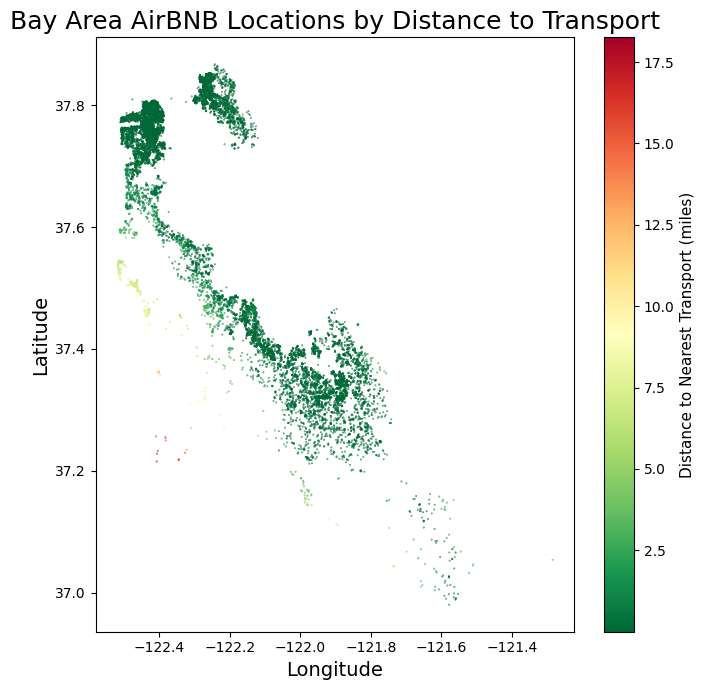

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

geometry = [Point(xy) for xy in zip(trimmed_df['longitude'], trimmed_df['latitude'])]
gdf_stops = gpd.GeoDataFrame(trimmed_df, geometry=geometry)

f, ax = plt.subplots(1, 1, figsize=(7, 7))

scatter = ax.scatter(
    gdf_stops['longitude'],
    gdf_stops['latitude'],
    c=gdf_stops['distance_nearest_transport'],
    cmap='RdYlGn_r',
    s=0.1
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Distance to Nearest Transport (miles)', fontsize=11)

ax.set_title('Bay Area AirBNB Locations by Distance to Transport', fontsize=18)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()

## Finding distance of each location from closest attraction

Note that each location was hand selected, then sourced it's latitude and longitude from mapcarta.com, then picked a category for each location.

In [ ]:
ATTRACTION_LIST = [
    'entertainment',
    'historic',
    'landmark',
    'nature',
    'tech_education'
]

In [ ]:
attractions = []
for attraction in ATTRACTION_LIST:
  attractions.append(pd.read_csv(f'https://raw.githubusercontent.com/JeremyAuradou/CSC215-FinalProject/refs/heads/main/attractions_{attraction}.csv', header=0, index_col=False))

print(f'Number of attraction dataframes: {len(attractions)}')

Number of attraction dataframes: 5


In [ ]:
from sklearn.neighbors import BallTree

for idx, attraction in enumerate(ATTRACTION_LIST):
  # BallTree expects radians for haversine
  airbnb_coords = np.deg2rad(trimmed_df[['latitude', 'longitude']].values)
  attraction_coords = np.deg2rad(attractions[idx-1][['latitude', 'longitude']].values)

  tree = BallTree(attraction_coords, metric='haversine') # Build the tree from attraction
  distances, indices = tree.query(airbnb_coords, k=3) # Query 3 nearest neighbors for each airbnb listing
  distances_miles = distances * 3958.8  # Convert from radians to miles (Earth radius = 3,958.8 miles)

  trimmed_df[f'distance_nearest_{attraction}'] = distances_miles[:, 0]  # Distance to closest stop

  display(trimmed_df[['latitude', 'longitude', f'distance_nearest_{attraction}']].head())

,latitude,longitude,distance_nearest_entertainment
0,37.810130,-122.292660,6.138864
1,37.812663,-122.258047,4.241386
2,37.831690,-122.251750,3.984481
3,37.836180,-122.255810,4.278581
4,37.834500,-122.262640,4.607728


,latitude,longitude,distance_nearest_historic
0,37.810130,-122.292660,1.771185
1,37.812663,-122.258047,0.295498
2,37.831690,-122.251750,1.651010
3,37.836180,-122.255810,1.910064
4,37.834500,-122.262640,1.783219


,latitude,longitude,distance_nearest_landmark
0,37.810130,-122.292660,1.670804
1,37.812663,-122.258047,1.519145
2,37.831690,-122.251750,2.860111
3,37.836180,-122.255810,3.084669
4,37.834500,-122.262640,2.892143


,latitude,longitude,distance_nearest_nature
0,37.810130,-122.292660,6.201161
1,37.812663,-122.258047,8.098611
2,37.831690,-122.251750,8.650456
3,37.836180,-122.255810,8.514738
4,37.834500,-122.262640,8.124501


,latitude,longitude,distance_nearest_tech_education
0,37.810130,-122.292660,1.867708
1,37.812663,-122.258047,0.385144
2,37.831690,-122.251750,1.739706
3,37.836180,-122.255810,2.014579
4,37.834500,-122.262640,1.904914


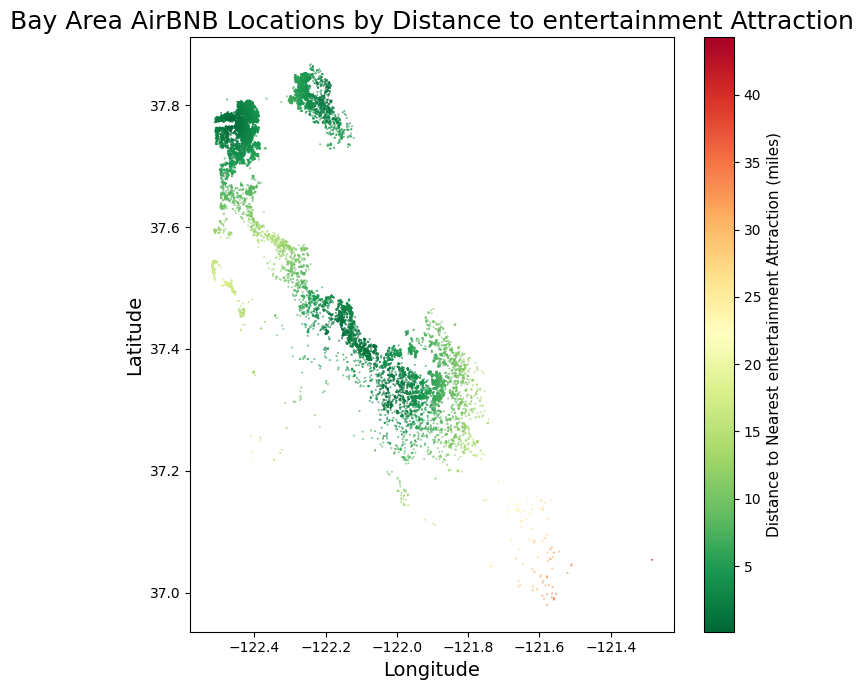

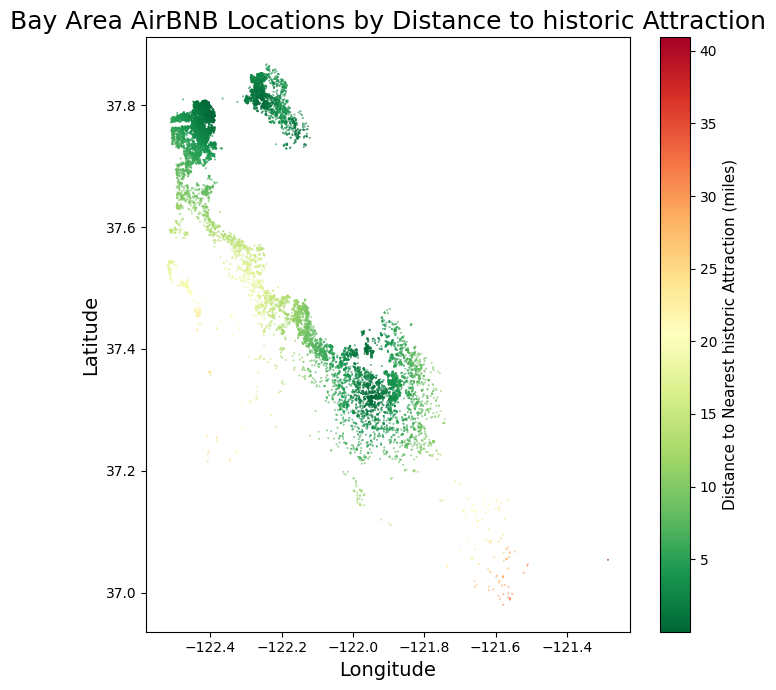

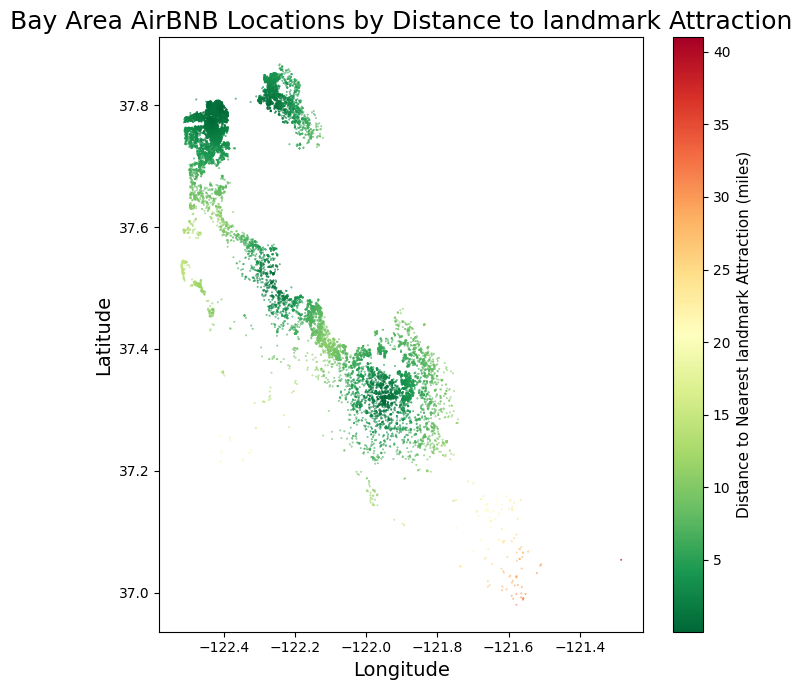

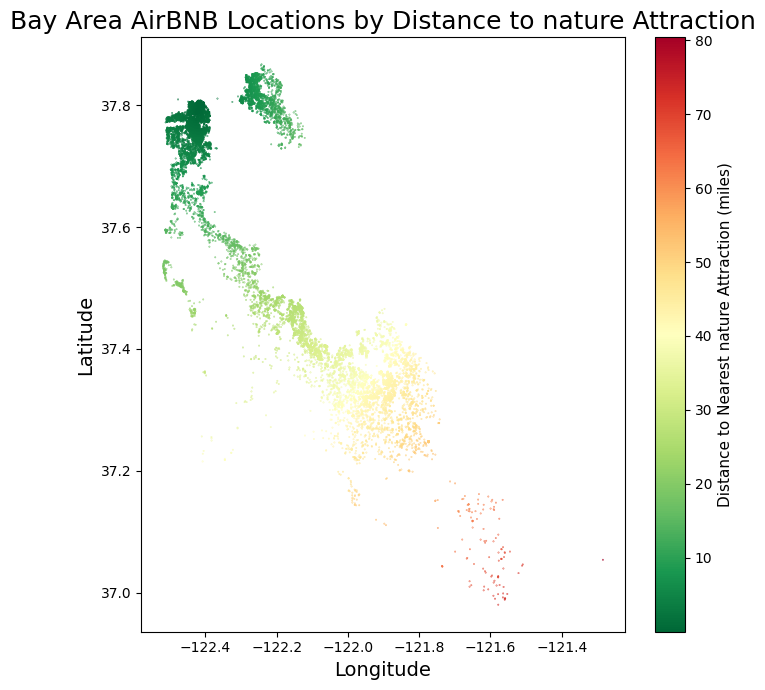

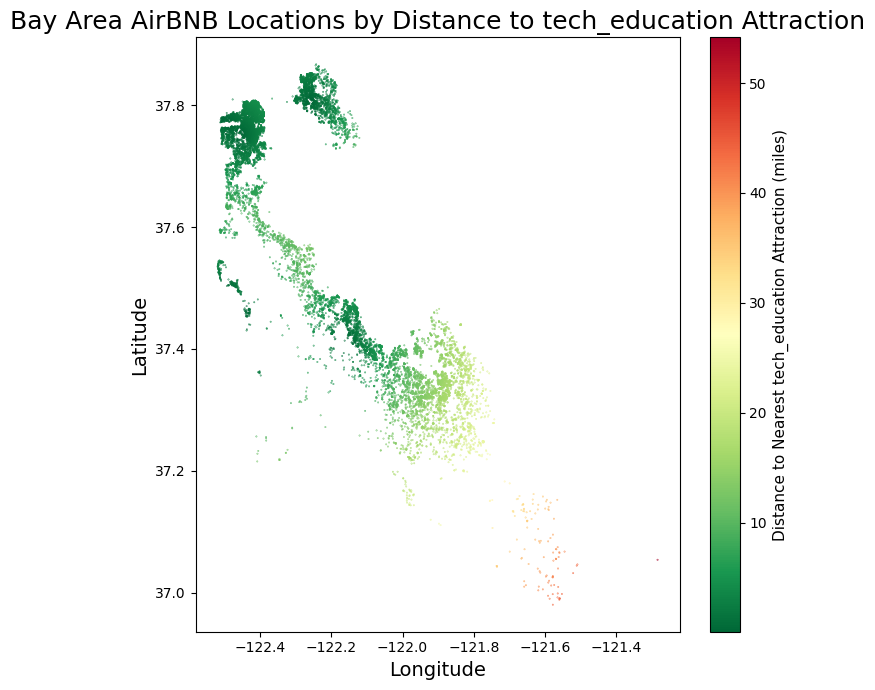

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

geometry = [Point(xy) for xy in zip(trimmed_df['longitude'], trimmed_df['latitude'])]
gdf_stops = gpd.GeoDataFrame(trimmed_df, geometry=geometry)


for attraction in ATTRACTION_LIST:
  f, ax = plt.subplots(1, 1, figsize=(7, 7))

  scatter = ax.scatter(
      gdf_stops['longitude'],
      gdf_stops['latitude'],
      c=gdf_stops[f'distance_nearest_{attraction}'],
      cmap='RdYlGn_r',
      s=0.1
  )

  cbar = plt.colorbar(scatter, ax=ax)
  cbar.set_label(f'Distance to Nearest {attraction} Attraction (miles)', fontsize=11)

  ax.set_title(f'Bay Area AirBNB Locations by Distance to {attraction} Attraction', fontsize=18)
  ax.set_xlabel('Longitude', fontsize=14)
  ax.set_ylabel('Latitude', fontsize=14)

  plt.tight_layout()
  plt.show()

## Generation Based on Pre-Existing Features

In [ ]:
trimmed_df['accommodates_per_bathrooms'] = (trimmed_df['accommodates'] / trimmed_df['bathrooms']).replace([np.inf, -np.inf], 0)
trimmed_df['accommodates_per_bedrooms'] = (trimmed_df['accommodates'] / trimmed_df['bedrooms']).replace([np.inf, -np.inf], 0)
trimmed_df['latitude_per_longitude'] = (trimmed_df['latitude'] / trimmed_df['longitude']).replace([np.inf, -np.inf], 0)

In [ ]:
print(trimmed_df.value_counts('bedrooms'))

bedrooms
0.693147    9336
1.098612    2888
1.386294    1563
0.000000    1098
1.609438     784
1.791759     232
1.945910      75
2.079442      31
2.197225      20
2.397895       6
2.302585       2
Name: count, dtype: int64


# Feature Selection

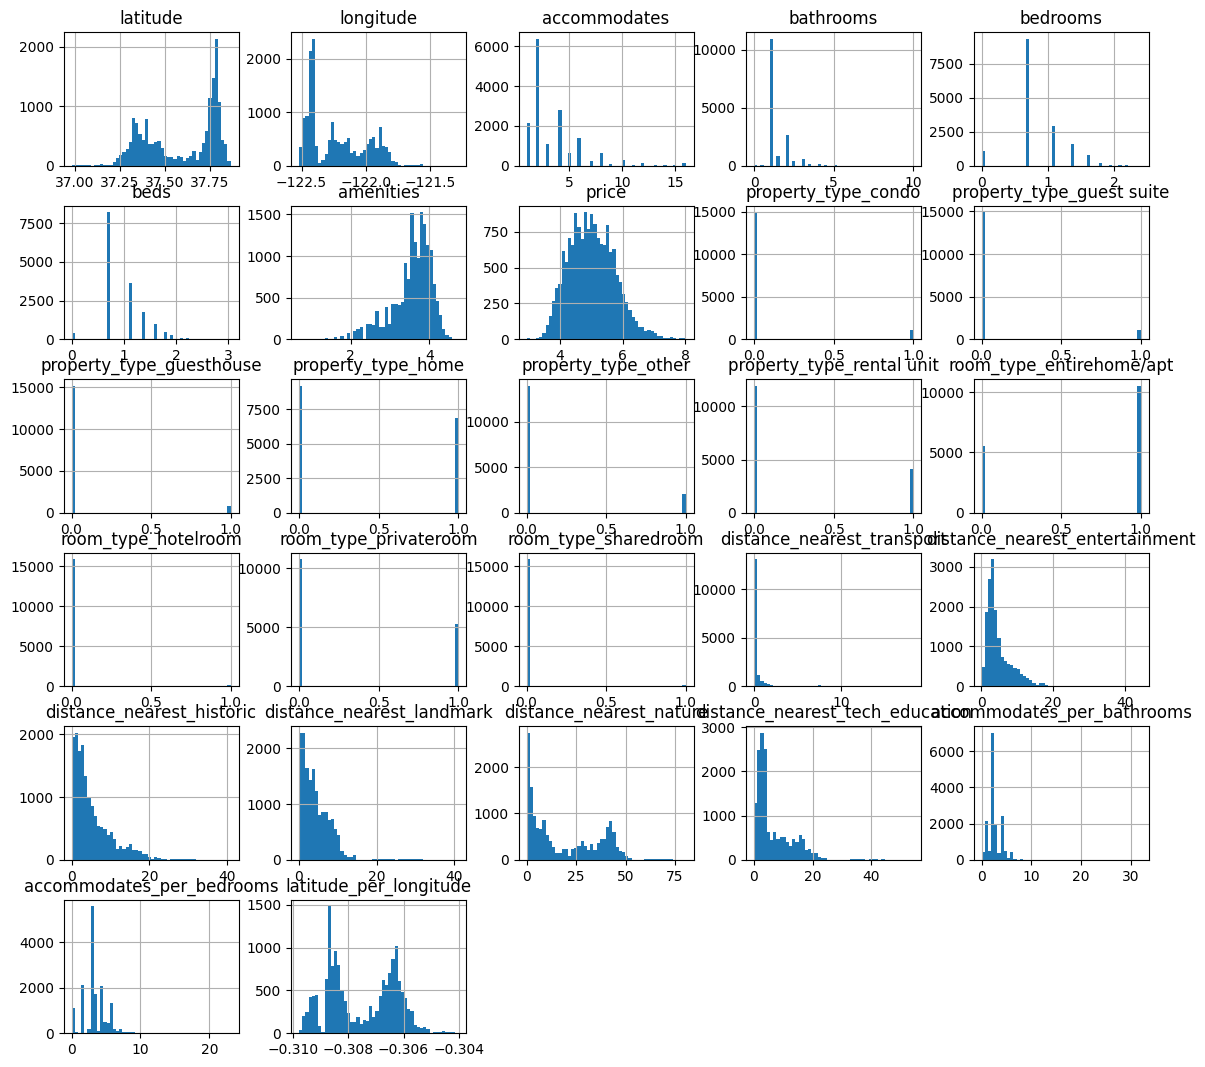

In [ ]:
trimmed_df.hist(bins=50, figsize=(14, 13))
plt.show()

In [ ]:
X = trimmed_df.drop(columns=['price'])
y = trimmed_df['price']
y = y.to_frame()

print(f'X.shape: {X.shape}')
print(f'y.shape: {y.shape}')

X.shape: (16035, 26)
y.shape: (16035, 1)


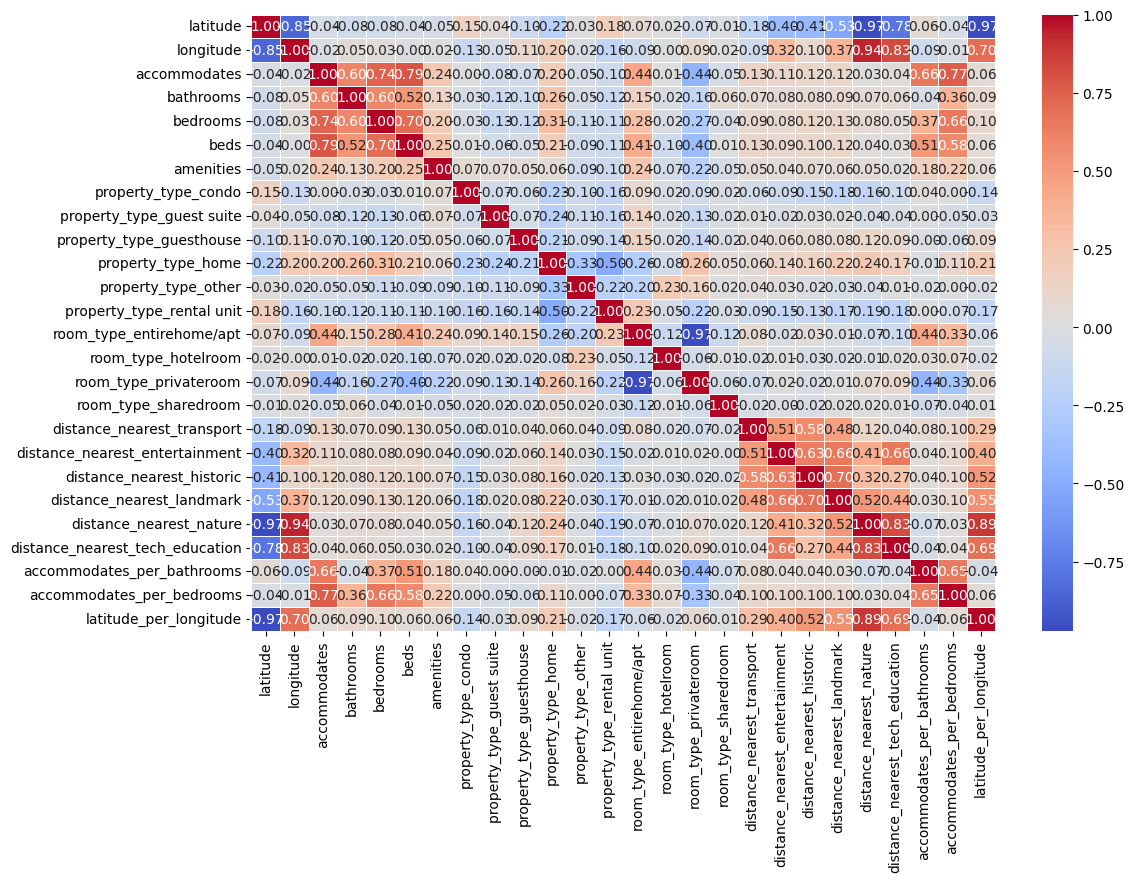

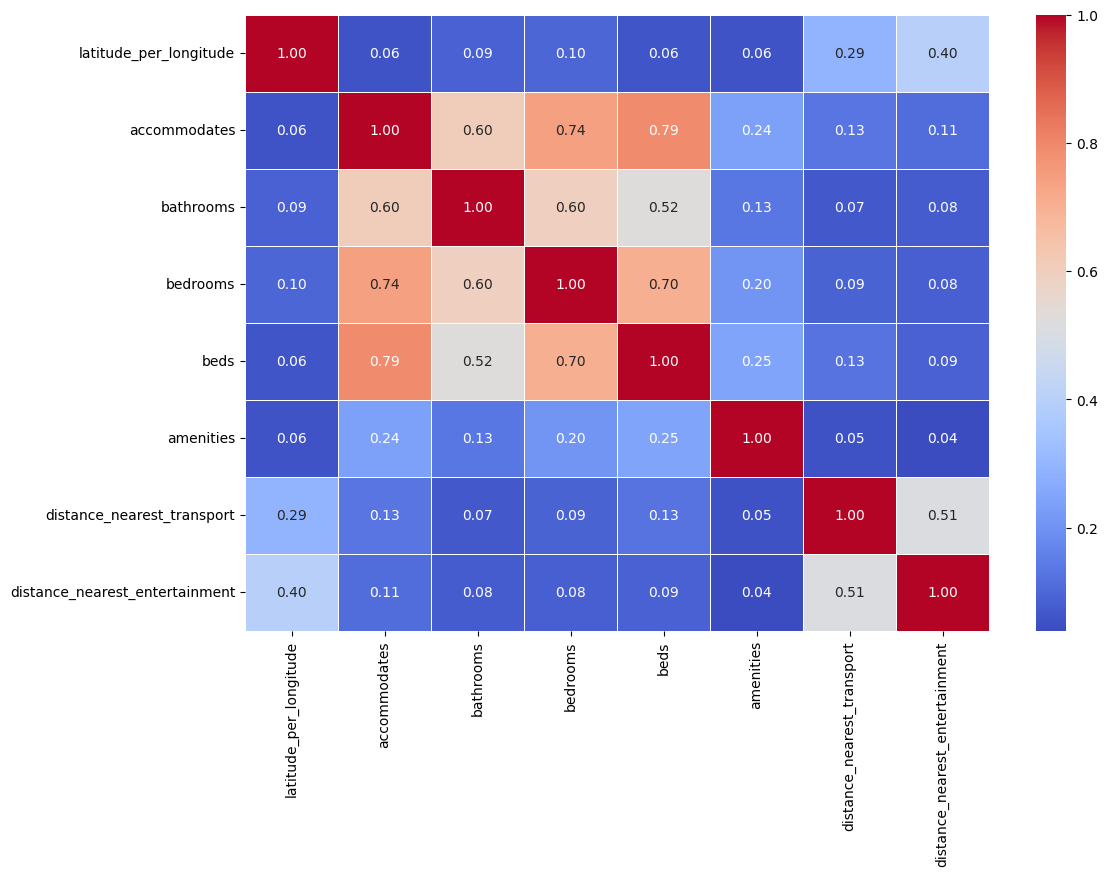

In [ ]:
# Sourced from "House_Price_Prediction" in lecture 3
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# AVOID Multi-Collinearity/Redundancy: features(Independent/Input) ==high +/-ve Linear correlation==> features(Independent/Input)
feats_X = X.loc[:, :]
useful_feats_corr = feats_X.corr('pearson')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target
plt.figure(figsize=(12,8))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')  # cmap='coolwarm|RdBu|BrBG|PRGn|viridis|Blues|Greens|Oranges|rocket|tab10|Set1|Pastel1|Accent'
plt.show()  # figsize(inch, inch) => (-ve corr., 0, +ve corr.)

'''
X_after_cleaning = X.drop(columns=[
    'latitude',
    'longitude',
    'latitude_per_longitude',
    'accommodates_per_bathrooms',
    'accommodates_per_bedrooms',
    'room_type_privateroom',
    'property_type_rental unit',
    'distance_nearest_nature',
])
'''
X_after_cleaning = X[['latitude_per_longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'distance_nearest_transport', 'distance_nearest_entertainment']]
feats_X = X_after_cleaning.loc[:, :]
useful_feats_corr = feats_X.corr('pearson')
plt.figure(figsize=(12,8))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()

# Feature Transformation

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

X = X_after_cleaning
class_y = feats_X.loc[:, ["accommodates"]]
print(X.shape)
print(y.shape)
print()

strat_data = StratifiedShuffleSplit(n_splits=1, test_size=0.2, train_size=0.8)
for train_index, test_index in strat_data.split(X, class_y):
  X_train, y_train = X.iloc[train_index], y.iloc[train_index]
  X_test, y_test = X.iloc[test_index], y.iloc[test_index]

print(f'X_train.shape: {X_train.shape}')
print(f'y_train.shape: {y_train.shape}')
print(f'X_test.shape: {X_test.shape}')
print(f'y_test.shape: {y_test.shape}')

(16035, 8)
(16035, 1)

X_train.shape: (12828, 8)
y_train.shape: (12828, 1)
X_test.shape: (3207, 8)
y_test.shape: (3207, 1)


In [ ]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

discrete_features = [
    'accommodates', 'bedrooms', 'beds',
    'bathrooms', 'amenities'
]

continuous_features = [
    'latitude_per_longitude',
    'distance_nearest_transport',
    'distance_nearest_entertainment',
    #'distance_nearest_historic',
    #'distance_nearest_landmark',
    #'distance_nearest_nature',
    #'distance_nearest_tech_education',
]

# One-hot encoded columns means no scaling needed
'''
one_hot_features = [
    'property_type_condo',
    'property_type_home',
    'property_type_other',
    'room_type_entirehome/apt',
    'room_type_privateroom',
    'room_type_sharedroom',
]
'''

preprocessor = ColumnTransformer(transformers=[
    ('quantile', QuantileTransformer(output_distribution='normal',
                                      n_quantiles=1000), continuous_features),
    ('standard', StandardScaler(), discrete_features)
    #('passthrough', 'passthrough', one_hot_features)
])

preprocessor.fit(X_train)
standized_X_train = preprocessor.transform(X_train)
standized_X_test = preprocessor.transform(X_test)

stdsc_y_scaler = StandardScaler()
stdsc_y_scaler = stdsc_y_scaler.fit(y_train)
standized_y_train = stdsc_y_scaler.transform(y_train)
standized_y_test = stdsc_y_scaler.transform(y_test)

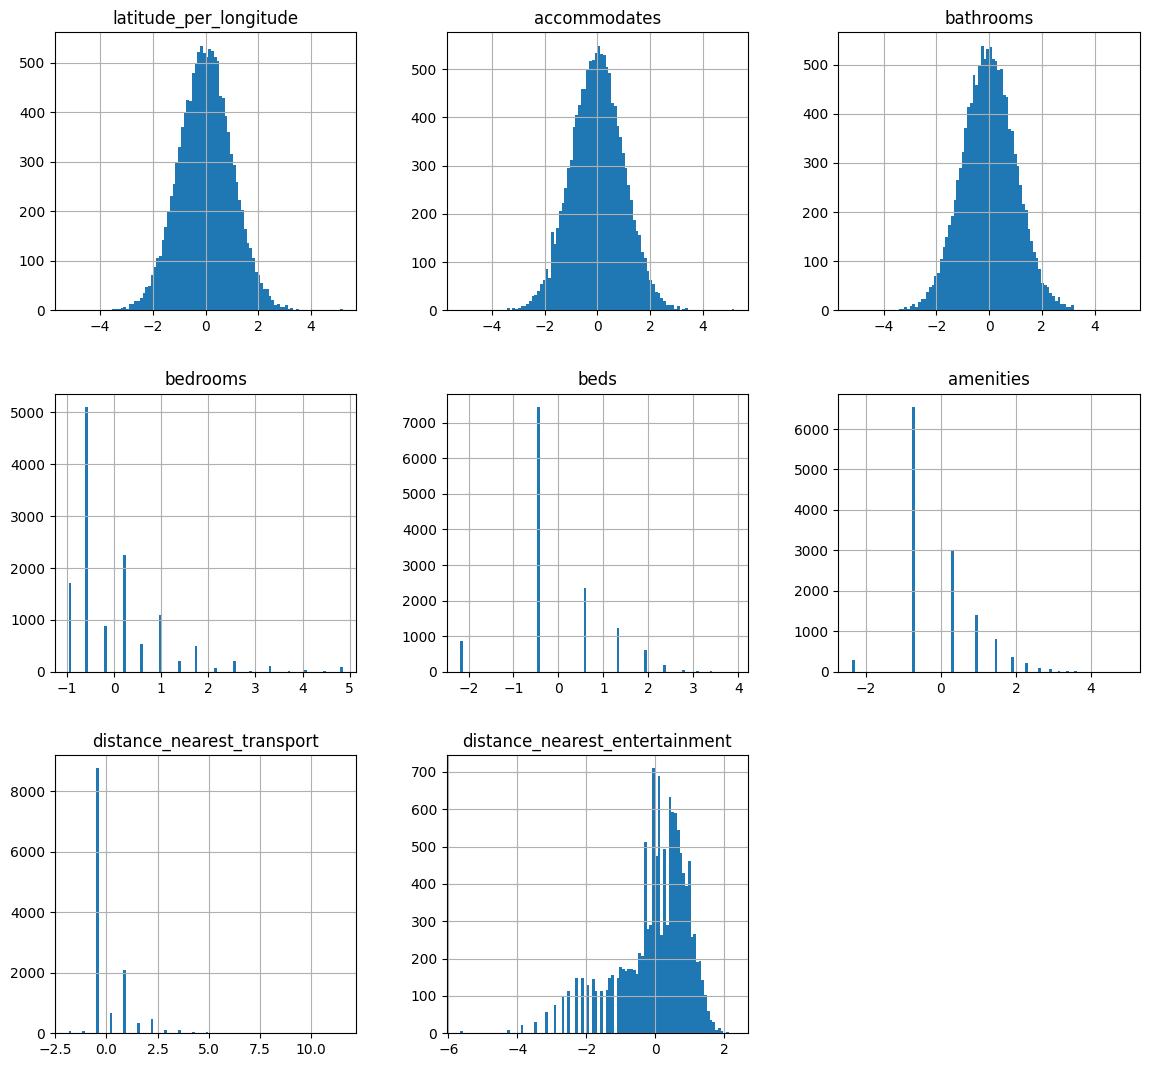

In [ ]:
pd.DataFrame(standized_X_train, columns=X_train.columns).hist(bins=100, figsize=(14, 13))

plt.show()

In [ ]:
# Select ML/DL algorithm AND Tune/Re-tune hyperparameters
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, BayesianRidge, ARDRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

ml_algorithm = "GradBoost"  # KNN, GradBoost, RandFrst, ExtraTree, DeciTree, etc

if (ml_algorithm == "LinearRegress"):
  algorithm = MultiOutputRegressor(LinearRegression())  # For regression only
elif (ml_algorithm == "LogisticRegress"):
  algorithm = MultiOutputClassifier(LogisticRegression(solver='lbfgs'))  # For classification only
elif (ml_algorithm == "SuppVec"):
  algorithm = MultiOutputRegressor(SVR(epsilon=0.1))
elif (ml_algorithm == "StochastGrad"):
  algorithm = MultiOutputRegressor(SGDRegressor(learning_rate='invscaling', eta0=0.01))
elif (ml_algorithm == "N_Bayes_Ridge"):
  algorithm = MultiOutputRegressor(BayesianRidge())
elif (ml_algorithm == "N_Bayes_ARD"):
  algorithm = MultiOutputRegressor(ARDRegression())
elif (ml_algorithm == "GradBoost"):
  algorithm = MultiOutputRegressor(GradientBoostingRegressor())
elif (ml_algorithm == "DeciTree"):
  algorithm = MultiOutputRegressor(DecisionTreeRegressor())
elif (ml_algorithm == "RandFrst"):
  algorithm = MultiOutputRegressor(RandomForestRegressor(n_estimators=100))
elif (ml_algorithm == "ExtraTree"):
  algorithm = MultiOutputRegressor(ExtraTreesRegressor(n_estimators=100))
elif (ml_algorithm == "KNN"):
  algorithm = MultiOutputRegressor(KNeighborsRegressor(n_neighbors=6, weights='distance'))
elif (ml_algorithm == "DL_MLP"):
  algorithm = MLPRegressor(hidden_layer_sizes=(standized_X_train.shape[1], 30, 50, 10, standized_y_train.shape[1]), activation='relu', solver='lbfgs', learning_rate='constant', learning_rate_init=0.001)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score

cv_preds = cross_val_predict(algorithm, standized_X_train, standized_y_train, cv=3, method='predict')
print("Shape of Output/Predictions: ", cv_preds.shape, "\n")
rescaled_y_train = stdsc_y_scaler.inverse_transform(pd.DataFrame(cv_preds))  # Since we used standard scaler on Y, need to convert back
rescaled_y_train = np.ceil(rescaled_y_train)

raw_y_train = y_train.values[:,:]
mae = mean_absolute_error(raw_y_train, rescaled_y_train)
mse = mean_squared_error(raw_y_train, rescaled_y_train)
rmse = np.sqrt(mse)
expvar = explained_variance_score(raw_y_train, rescaled_y_train, multioutput='raw_values')  # BEST=1.0, WORST=0.0
r2 = r2_score(raw_y_train, rescaled_y_train, multioutput='raw_values')  # BEST=1.0, WORST=0.0

# Training Metrics
print("Training Metrics: ", "\n----------------")
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse )
print("EXP_VAR: ", expvar)
print("R2: ", r2)

Shape of Output/Predictions:  (12828, 1) 

Training Metrics:  
----------------
MAE:  0.6051792691018782
MSE:  0.5269447257090566
RMSE:  0.7259095850786492
EXP_VAR:  [0.46084387]
R2:  [0.0326733]


In [ ]:
# TESTING/GENERALIZATION: Make Predictions for 'y-component' wrt. data(Test)
model = algorithm
model.fit(standized_X_train, standized_y_train)
pred_y_test = model.predict(standized_X_test)
rescaled_y_test = stdsc_y_scaler.inverse_transform(pd.DataFrame(pred_y_test))  # Invert Scaling: For 'y-component' only
rescaled_y_test = np.ceil(rescaled_y_test)

# Evaluate model's performance. Overfitting(Train MSE << Test MSE); Underfitting(Train MSE >> Test MSE).
raw_y_test = y_test.values[:,:]
mae = mean_absolute_error(raw_y_test, rescaled_y_test)
mse = mean_squared_error(raw_y_test, rescaled_y_test)
rmse = np.sqrt(mse)
expvar = explained_variance_score(raw_y_test, rescaled_y_test, multioutput='raw_values')  # BEST=1.0, WORST=0.0
r2 = r2_score(raw_y_test, rescaled_y_test, multioutput='raw_values')  # BEST=1.0, WORST=0.0

# Testing Metrics
print("Testing Metrics: ", "\n----------------")
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse )
print("EXP_VAR: ", expvar)
print("R2: ", r2)

# head() of values(GroundTruth) and values(Prediction)
print("\nhead() of 'raw_y_test': ", "\n-----------------------")
print(raw_y_test[0:10, :])
print("\nhead() of 'reversed_y_test': ", "\n-----------------------")
print(reversed_y_test[0:10, :])

Testing Metrics:  
----------------
MAE:  0.5913742573585576
MSE:  0.5009772405484082
RMSE:  0.7077974572915674
EXP_VAR:  [0.47354387]
R2:  [0.07118418]

head() of 'raw_y_test':  
-----------------------
[[3.8501476 ]
 [4.82028157]
 [4.51085951]
 [5.63835467]
 [4.66343909]
 [4.30406509]
 [5.34710753]
 [5.84643878]
 [3.8286414 ]
 [5.69035945]]

head() of 'reversed_y_test':  
-----------------------
[[215.]
 [259.]
 [131.]
 [546.]
 [163.]
 [187.]
 [ 99.]
 [183.]
 [ 82.]
 [102.]]
